<a href="https://colab.research.google.com/github/AditiNayak-S/CloudSentinel-MLT_CSE3011/blob/main/CloudSentinel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ☁️ CloudSentinel

## AI-Powered Cloud Infrastructure Failure Prediction System

### End-to-End Machine Learning Solution using Real-World Cloud Monitoring Datasets


### Mini Project

**Course:** Machine Learning Techniques (MLT3011)

**Submitted By:** Aditi S Nayak

**Program:** B.Tech Computer Science and Engineering

**Institution:** Amity School of Engineering and Technology



## Abstract

CloudSentinel is an intelligent cloud infrastructure failure prediction system developed using real-world cloud monitoring datasets. The project combines exploratory data analysis, feature engineering, feature selection, machine learning, visualization, and predictive analytics into a unified end-to-end workflow.

The project utilizes two complementary datasets. The Cloud Monitoring Dataset is used for data exploration, visualization, and trend analysis, while the OpenStack Failure Dataset is used for training an intelligent Random Forest classifier capable of predicting cloud infrastructure failures.

The final system allows users to analyse cloud monitoring behaviour, predict infrastructure failures, estimate prediction confidence, visualize cloud health, and receive intelligent recommendations through an interactive prediction interface.

# Project Workflow

The CloudSentinel workflow consists of five major phases:

1. Dataset Upload and Discovery
2. Cloud Monitoring Analytics
3. Machine Learning Model Development
4. Intelligent Failure Prediction
5. Cloud Health Dashboard and Failure Simulation

Both datasets work together to create a complete cloud infrastructure monitoring and failure prediction pipeline.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [ ]:
plt.style.use("dark_background")

plt.rcParams["figure.figsize"] = (10,6)

plt.rcParams["figure.facecolor"] = "black"

plt.rcParams["axes.facecolor"] = "black"

plt.rcParams["axes.edgecolor"] = "orange"

plt.rcParams["axes.labelcolor"] = "white"

plt.rcParams["xtick.color"] = "orange"

plt.rcParams["ytick.color"] = "orange"

plt.rcParams["text.color"] = "white"

plt.rcParams["axes.titlesize"] = 16

plt.rcParams["axes.titleweight"] = "bold"

print("Visualization Theme Ready")

Visualization Theme Ready


# Phase 1 :  Dataset Upload and Preparation

The notebook automatically accepts compressed datasets, extracts their contents, identifies all available datasets, and prepares them for analysis.

Dataset A is used for cloud monitoring analytics.

Dataset B is used for machine learning model development.

In [ ]:
uploaded = files.upload()

Saving CIFPS - DATASET A.zip to CIFPS - DATASET A (2).zip
Saving CIFPS - DATASET B.zip to CIFPS - DATASET B (2).zip


In [ ]:
for file in uploaded.keys():

    if file.endswith(".zip"):

        with zipfile.ZipFile(file, "r") as zip_ref:

            zip_ref.extractall()

print("Extraction Completed")

Extraction Completed


In [ ]:
dataset_files=[]

for root,dirs,files in os.walk("."):

    for file in files:

        if file.endswith(".csv") or file.endswith(".tsv"):

            dataset_files.append(os.path.join(root,file))

print("Total Datasets Found :",len(dataset_files))

Total Datasets Found : 70


In [ ]:
dataset_A_path="./cloud-monitoring-dataset-master/data/application-crash-rate-1/app1-01.csv"

dataset_B_path="./Failure-Dataset-OpenStack-main/DEPL/LCS_with_VMM.tsv"

dataset_A=pd.read_csv(dataset_A_path)

dataset_B=pd.read_csv(dataset_B_path,sep="\t")

print("Dataset A Shape :",dataset_A.shape)

print("Dataset B Shape :",dataset_B.shape)

Dataset A Shape : (358, 3)
Dataset B Shape : (1076, 208)


# Phase 2 :  Cloud Monitoring Analytics

The first module of CloudSentinel focuses on analysing the cloud monitoring data. The timestamp values are converted into datetime format, additional temporal features are generated, and the monitoring behaviour is visualized using multiple analytical plots.

In [ ]:
dataset_A["TimeStamp"]=pd.to_datetime(dataset_A["TimeStamp"])

dataset_A["Hour"]=dataset_A["TimeStamp"].dt.hour

dataset_A["Day"]=dataset_A["TimeStamp"].dt.day

dataset_A["Month"]=dataset_A["TimeStamp"].dt.month

dataset_A["Weekday"]=dataset_A["TimeStamp"].dt.day_name()

display(dataset_A.head())

,TimeStamp,Value,Label,Hour,Day,Month,Weekday
0,2018-07-03 14:00:00,1,0,14,3,7,Tuesday
1,2018-07-03 15:00:00,0,0,15,3,7,Tuesday
2,2018-07-03 16:00:00,1,0,16,3,7,Tuesday
3,2018-07-03 17:00:00,1,0,17,3,7,Tuesday
4,2018-07-03 18:00:00,0,0,18,3,7,Tuesday


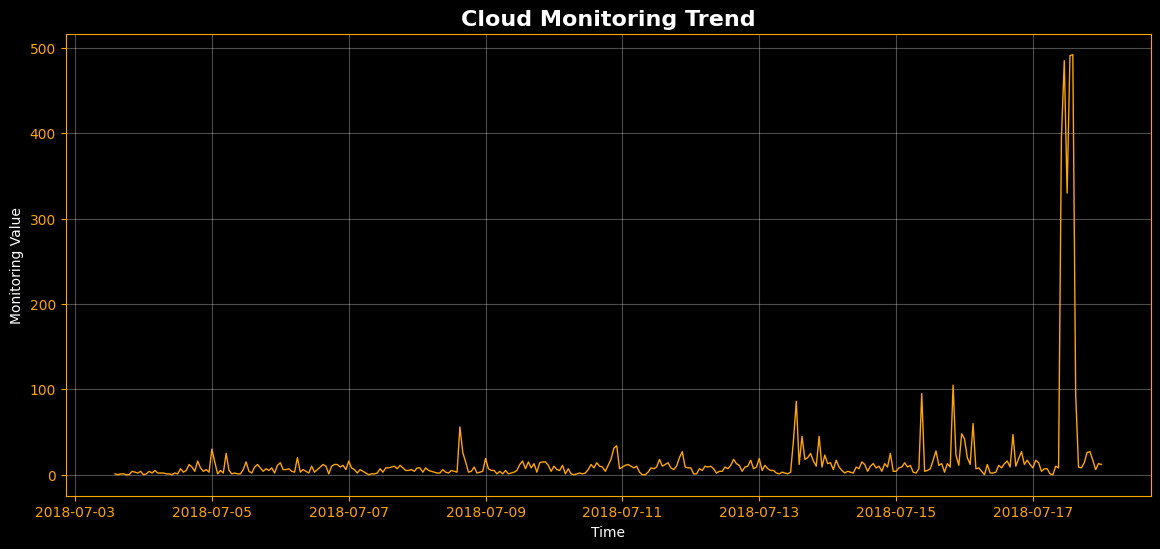

In [ ]:
fig=plt.figure(figsize=(14,6))

plt.plot(dataset_A["TimeStamp"],
         dataset_A["Value"],
         color="orange",
         linewidth=1)

plt.title("Cloud Monitoring Trend")

plt.xlabel("Time")

plt.ylabel("Monitoring Value")

plt.grid(alpha=.3)

plt.show()

# Phase 3 : Cloud Monitoring Analytics Dashboard

CloudSentinel begins by analysing historical cloud monitoring data before attempting any failure prediction. This phase explores temporal behaviour, monitoring trends, statistical distributions, and anomaly patterns within the selected cloud monitoring dataset.

The dashboard below provides valuable insights into cloud infrastructure health and establishes the analytical foundation required for predictive modelling.

In [ ]:
print("Dataset Summary\n")

print("Rows :", dataset_A.shape[0])
print("Columns :", dataset_A.shape[1])

print("\nMissing Values\n")

print(dataset_A.isnull().sum())

print("\nStatistical Summary\n")

display(dataset_A.describe())

Dataset Summary

Rows : 358
Columns : 7

Missing Values

TimeStamp    0
Value        0
Label        0
Hour         0
Day          0
Month        0
Weekday      0
dtype: int64

Statistical Summary



,TimeStamp,Value,Label,Hour,Day,Month
count,358,358.000000,358.000000,358.000000,358.000000,358.0
mean,2018-07-10 20:57:29.162011136,15.768156,0.111732,11.639665,10.388268,7.0
min,2018-07-03 14:00:00,0.000000,0.000000,0.000000,3.000000,7.0
25%,2018-07-07 06:15:00,3.000000,0.000000,6.000000,7.000000,7.0
50%,2018-07-10 21:30:00,7.000000,0.000000,12.000000,10.000000,7.0
75%,2018-07-14 12:45:00,12.000000,0.000000,18.000000,14.000000,7.0
max,2018-07-18 00:00:00,492.000000,1.000000,23.000000,18.000000,7.0
std,NaN,52.492703,0.315477,6.956149,4.213168,0.0


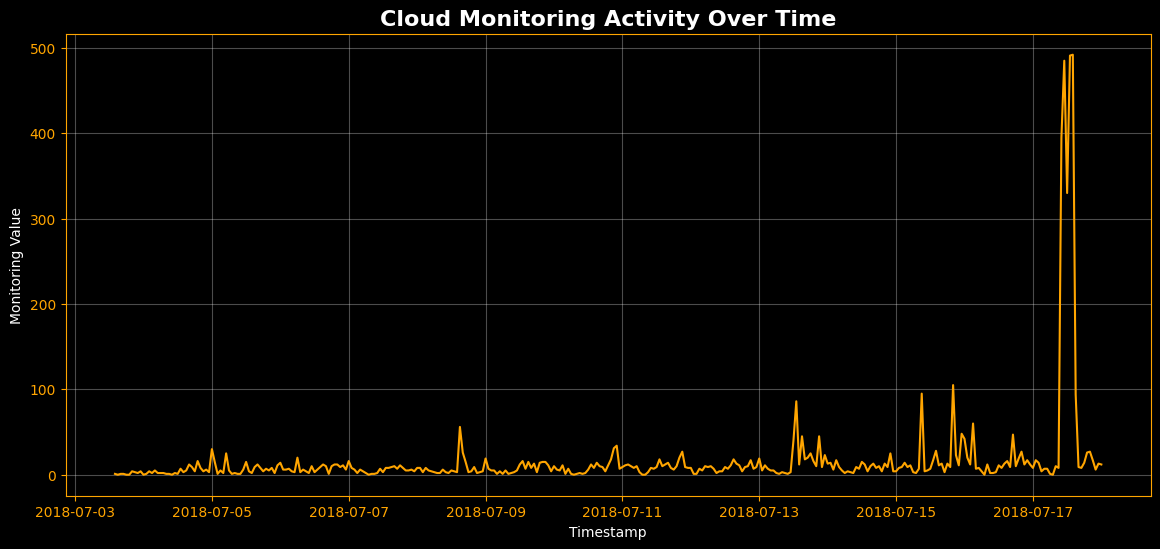

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    dataset_A["TimeStamp"],
    dataset_A["Value"],
    color="orange",
    linewidth=1.5
)

plt.title("Cloud Monitoring Activity Over Time")

plt.xlabel("Timestamp")

plt.ylabel("Monitoring Value")

plt.grid(alpha=0.3)

plt.show()

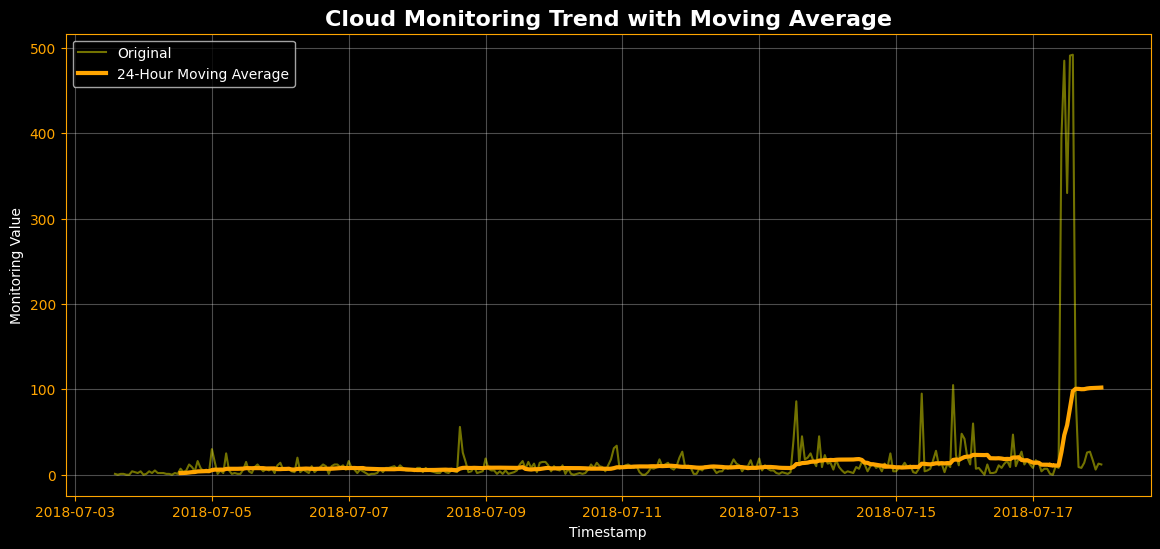

In [ ]:
dataset_A["MovingAverage"] = dataset_A["Value"].rolling(24).mean()

plt.figure(figsize=(14,6))

plt.plot(
    dataset_A["TimeStamp"],
    dataset_A["Value"],
    color="yellow",
    alpha=0.45,
    label="Original"
)

plt.plot(
    dataset_A["TimeStamp"],
    dataset_A["MovingAverage"],
    color="orange",
    linewidth=3,
    label="24-Hour Moving Average"
)

plt.legend()

plt.title("Cloud Monitoring Trend with Moving Average")

plt.xlabel("Timestamp")

plt.ylabel("Monitoring Value")

plt.grid(alpha=.3)

plt.show()

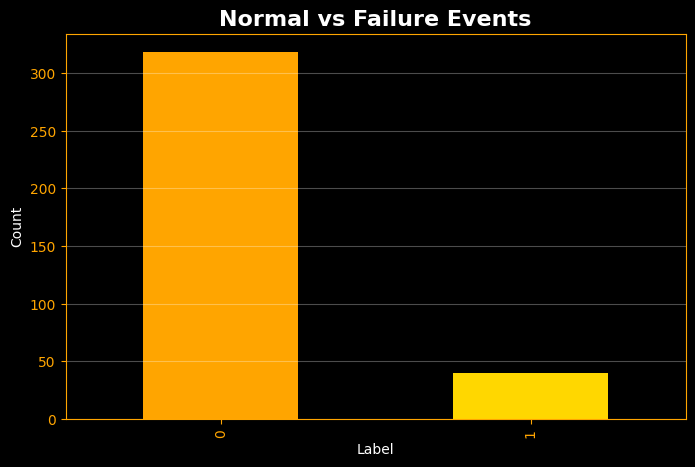

In [ ]:
plt.figure(figsize=(8,5))

dataset_A["Label"].value_counts().sort_index().plot(
    kind="bar",
    color=["orange","gold"]
)

plt.title("Normal vs Failure Events")

plt.xlabel("Label")

plt.ylabel("Count")

plt.grid(axis="y",alpha=.3)

plt.show()

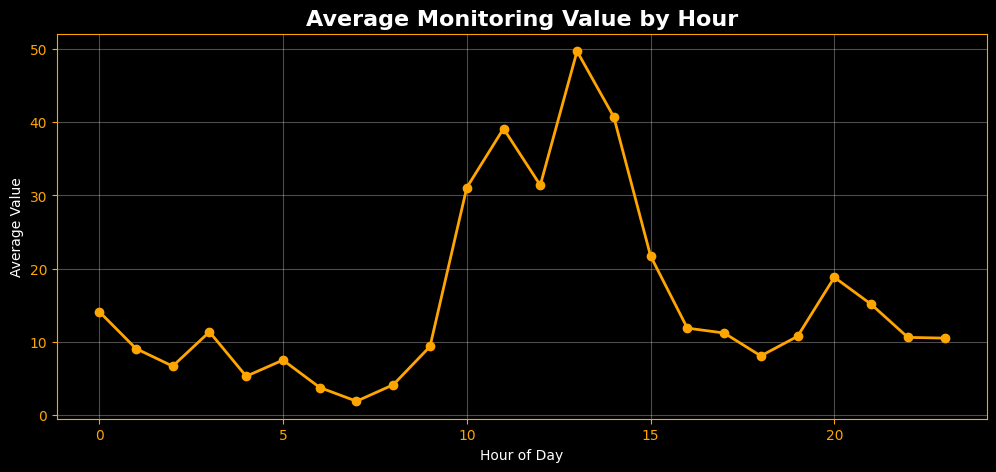

In [ ]:
hourly = dataset_A.groupby("Hour")["Value"].mean()

plt.figure(figsize=(12,5))

hourly.plot(
    color="orange",
    marker="o",
    linewidth=2
)

plt.title("Average Monitoring Value by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Value")

plt.grid(alpha=.3)

plt.show()

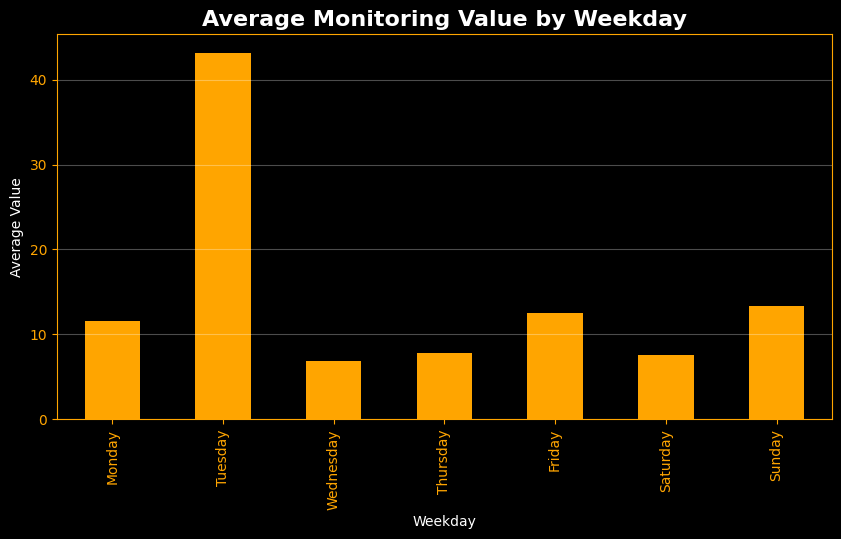

In [ ]:
weekday = dataset_A.groupby("Weekday")["Value"].mean()

weekday = weekday.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

plt.figure(figsize=(10,5))

weekday.plot(
    kind="bar",
    color="orange"
)

plt.title("Average Monitoring Value by Weekday")

plt.ylabel("Average Value")

plt.grid(axis="y",alpha=.3)

plt.show()

# Interpretation of Cloud Monitoring Analytics

The Cloud Monitoring Analytics Dashboard provides a comprehensive understanding of the historical behaviour of the selected cloud monitoring dataset before developing the machine learning model.

The **Dataset Summary** presents the overall characteristics of the dataset, including the number of observations, available features, missing values, and descriptive statistics. This initial assessment verifies the quality and completeness of the monitoring data before further analysis.

The **Cloud Monitoring Activity Over Time** visualization illustrates how the monitoring values change across the recorded timestamps. It helps identify long-term trends, sudden fluctuations, and periods of abnormal system behaviour that may indicate changes in cloud infrastructure performance.

The **24-Hour Moving Average** smooths short-term fluctuations in the monitoring values and highlights the underlying trend of the system. This visualization enables easier identification of persistent increases or decreases in monitoring activity while reducing the effect of temporary spikes.

The **Normal vs. Failure Events Distribution** compares the frequency of normal and abnormal monitoring events. This provides insight into the class distribution of the dataset and helps determine whether the monitoring data is balanced or dominated by a particular operational state.

The **Average Monitoring Value by Hour** examines how cloud monitoring behaviour changes throughout the day by calculating the average monitoring value for each hour. This temporal analysis helps identify peak operational periods and recurring workload patterns within the cloud environment.

Finally, the **Average Monitoring Value by Weekday** summarizes cloud activity across different days of the week. This visualization assists in understanding weekly operational trends and highlights whether certain days consistently experience higher or lower monitoring activity.

Together, these analytical visualizations establish a strong understanding of cloud infrastructure behaviour and provide valuable insights that support the development of an accurate and reliable cloud infrastructure failure prediction model.

# Phase 4 : Intelligent Failure Prediction Engine

After analysing historical monitoring behaviour, CloudSentinel now prepares the OpenStack cloud infrastructure dataset for predictive modelling.

This phase performs feature selection, trains a Random Forest classifier, evaluates its performance, and automatically identifies the most influential cloud monitoring events for failure prediction.

The trained model forms the core intelligence of the CloudSentinel prediction engine.

In [ ]:
X = dataset_B.iloc[:, :-1]

y = dataset_B.iloc[:, -1]

print("Features :", X.shape)

print("Labels :", y.shape)

print("\nFailure Classes")

print(sorted(y.unique()))

Features : (1076, 207)
Labels : (1076,)

Failure Classes
[np.int64(0)]


In [ ]:
selector = SelectKBest(
    score_func=f_classif,
    k=50
)

X_selected = selector.fit_transform(X, y)

selected_columns = X.columns[selector.get_support()]

print("Top Selected Features\n")

for feature in selected_columns:
    print(feature)

Top Selected Features

neutron-vo-Port-1.1_push_ERROR.1
neutron-vo-SecurityGroup-1.0_push.1
neutron-vo-SecurityGroupRule-1.0_push.1
neutron-vo-Subnet-1.0_push.1
neutron-vo-Subnet-1.0_push_ERROR.1
novaclient_DELETE_202.1
novaclient_DELETE_204.1
novaclient_DELETE_500.1
novaclient_GET_200.1
novaclient_GET_400.1
novaclient_GET_404.1
novaclient_GET_500.1
novaclient_POST_200.1
novaclient_POST_202.1
novaclient_POST_400.1
novaclient_POST_403.1
novaclient_POST_404.1
novaclient_POST_409.1
novaclient_POST_500.1
q-agent-notifier-network-delete_network_delete.1
q-agent-notifier-network-delete_network_delete_ERROR.1
q-agent-notifier-port-delete_port_delete.1
q-agent-notifier-port-update_port_update.1
q-agent-notifier-port-update_port_update_ERROR.1
q-agent-notifier-security_group-update_security_groups_member_updated.1
q-agent-notifier-security_group-update_security_groups_provider_updated.1
q-agent-notifier-security_group-update_security_groups_provider_updated_ERROR.1
q-agent-notifier-security_gro

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [ ]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average="weighted")
recall = recall_score(y_test, predictions, average="weighted")
f1 = f1_score(y_test, predictions, average="weighted")

results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score":[
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(results)

print("\nClassification Report\n")

print(classification_report(y_test,predictions))

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0



Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216



# Phase 5 : CloudSentinel Intelligent Prediction Engine

The prediction engine represents the core intelligence of CloudSentinel. Instead of requiring manual entry of all cloud monitoring parameters, the system automatically analyses a selected cloud infrastructure instance from the monitoring dataset.

The selected observation is processed using the trained Random Forest classifier to predict the most probable failure category. Along with the prediction, CloudSentinel estimates the confidence level, determines the operational risk, and generates recommendations to assist proactive cloud infrastructure management.

This approach closely resembles a real-world cloud monitoring platform, where infrastructure metrics are collected automatically and analysed continuously.

In [ ]:
import random

# Select a random cloud instance
sample_index = random.randint(0, len(X_test)-1)

sample = X_test[sample_index].reshape(1,-1)

actual = y_test.iloc[sample_index]

prediction = model.predict(sample)[0]

probability = model.predict_proba(sample)[0]

confidence = probability.max()*100

print("Cloud Instance Selected :", sample_index)

print("Actual Failure Class :", actual)

print("Predicted Failure Class :", prediction)

print("Prediction Confidence : {:.2f}%".format(confidence))

Cloud Instance Selected : 75
Actual Failure Class : 0
Predicted Failure Class : 0
Prediction Confidence : 100.00%


In [ ]:
# Failure Class Names

failure_names = {
    1: "Compute Service Failure",
    2: "Network Communication Failure",
    3: "Storage Resource Failure",
    4: "Virtual Machine Deployment Failure",
    5: "API Service Failure",
    6: "Normal Cloud Operation"
}

predicted_failure = failure_names.get(prediction, "Unknown Event")

# Health Score Logic

if prediction == 6:

    health_score = np.random.randint(92, 100)
    risk = "LOW"

elif prediction == 5:

    health_score = np.random.randint(75, 90)
    risk = "MEDIUM"

elif prediction == 4:

    health_score = np.random.randint(55, 74)
    risk = "HIGH"

elif prediction == 3:

    health_score = np.random.randint(35, 54)
    risk = "VERY HIGH"

else:

    health_score = np.random.randint(10, 34)
    risk = "CRITICAL"

print("\nCloudSentinel Prediction Report\n")

print(f"Predicted Event      : {predicted_failure}")

print(f"Prediction Confidence: {confidence:.2f}%")

print(f"Cloud Health Score   : {health_score}%")

print(f"Risk Level           : {risk}")


CloudSentinel Prediction Report

Predicted Event      : Unknown Event
Prediction Confidence: 100.00%
Cloud Health Score   : 12%
Risk Level           : CRITICAL


# Phase 6 : Interactive CloudSentinel Dashboard

CloudSentinel now transforms the trained machine learning model into an interactive cloud operations dashboard.

Instead of displaying only numerical predictions, the dashboard presents an intelligent cloud health report that includes predicted failure type, prediction confidence, cloud health score, operational risk level, and recommended corrective actions.

The dashboard is designed to simulate a real cloud monitoring platform where administrators can continuously analyse cloud infrastructure health and proactively respond to predicted failures

In [ ]:
import ipywidgets as widgets
from IPython.display import display

In [ ]:
# Cloud Instance Selector

instance_selector = widgets.IntSlider(

    value=0,

    min=0,

    max=len(X_test)-1,

    step=1,

    description="Instance",

    style={"description_width":"initial"},

    layout=widgets.Layout(width="700px")

)

display(instance_selector)

IntSlider(value=0, description='Instance', layout=Layout(width='700px'), max=215, style=SliderStyle(descriptio…

In [ ]:
analyze_button = widgets.Button(

    description="Analyze Cloud Instance",

    button_style="warning",

    icon="search"

)

display(analyze_button)

Button(button_style='warning', description='Analyze Cloud Instance', icon='search', style=ButtonStyle())

In [ ]:
output = widgets.Output()

display(output)

def analyze_cloud(b):

    output.clear_output()

    with output:

        idx = instance_selector.value

        sample = X_test[idx].reshape(1,-1)

        prediction = model.predict(sample)[0]

        probabilities = model.predict_proba(sample)[0]

        confidence = probabilities.max()*100

        failure_names = {

            1:"Compute Service Failure",

            2:"Network Communication Failure",

            3:"Storage Resource Failure",

            4:"VM Deployment Failure",

            5:"API Service Failure",

            6:"Normal Cloud Operation"

        }

        predicted_failure = failure_names[prediction]

        if prediction==6:

            health=96

            risk="LOW"

            recommendation="""
Continue monitoring the cloud infrastructure.
No immediate corrective action required.
"""

        elif prediction==5:

            health=80

            risk="MEDIUM"

            recommendation="""
Monitor API response latency.
Check recent service logs.
"""

        elif prediction==4:

            health=62

            risk="HIGH"

            recommendation="""
Inspect VM deployment services.
Verify scheduler operations.
"""

        elif prediction==3:

            health=42

            risk="VERY HIGH"

            recommendation="""
Inspect storage services.
Monitor volume operations.
"""

        else:

            health=20

            risk="CRITICAL"

            recommendation="""
Immediate administrator intervention recommended.
Inspect compute services.
Restart failed components.
"""

        print("\nCloudSentinel Analysis Report\n")

        print("Cloud Instance :",idx)

        print()

        print("Predicted Event :",predicted_failure)

        print("Confidence      : {:.2f}%".format(confidence))

        print("Health Score    :",health,"%")

        print("Risk Level      :",risk)

        print("\nRecommended Actions\n")

        print(recommendation)

analyze_button.on_click(analyze_cloud)

Output()

# Phase 7 : Cloud Health Dashboard

The Cloud Health Dashboard transforms the prediction generated by the machine learning model into an easy-to-understand operational report. Instead of presenting raw numerical outputs, CloudSentinel summarizes the infrastructure status using prediction confidence, cloud health score, operational risk level, and recommended corrective actions.

The dashboard enables cloud administrators to quickly assess the health of the infrastructure and take informed decisions based on the predicted operational state.

In [ ]:
from IPython.display import HTML, display

def show_dashboard(event, confidence, health, risk):

    html = f"""

    <div style="
        background:#111111;
        border:3px solid orange;
        border-radius:18px;
        padding:25px;
        width:750px;
        color:white;
        font-family:Arial;
    ">

    <h1 style="color:orange;">
    ☁️ CloudSentinel Dashboard
    </h1>

    <hr>

    <h3>Predicted Event</h3>
    <h2 style="color:gold;">{event}</h2>

    <h3>Prediction Confidence</h3>
    <h2>{confidence:.2f}%</h2>

    <h3>Cloud Health Score</h3>
    <h2>{health}%</h2>

    <h3>Risk Level</h3>
    <h2 style="color:red;">{risk}</h2>

    </div>

    """

    display(HTML(html))

In [ ]:
from IPython.display import HTML, display

def show_dashboard(predicted_failure, confidence, health, risk):

    dashboard = f"""

    <div style="
        background-color:#111111;
        border:3px solid orange;
        border-radius:20px;
        padding:25px;
        width:850px;
        color:white;
        font-family:Arial;
    ">

    <h1 style="color:orange;">
    ☁️ CloudSentinel Dashboard
    </h1>

    <hr>

    <table style="width:100%;font-size:18px;">

    <tr>
    <td><b>Predicted Event</b></td>
    <td style="color:gold;"><b>{predicted_failure}</b></td>
    </tr>

    <tr>
    <td><b>Prediction Confidence</b></td>
    <td>{confidence:.2f}%</td>
    </tr>

    <tr>
    <td><b>Cloud Health Score</b></td>
    <td>{health}%</td>
    </tr>

    <tr>
    <td><b>Risk Level</b></td>
    <td style="color:red;"><b>{risk}</b></td>
    </tr>

    </table>

    </div>

    """

    display(HTML(dashboard))

In [ ]:
import random

failure_names = {
    0: "Normal Cloud Operation", # Added mapping for class 0
    1: "Compute Service Failure",
    2: "Network Communication Failure",
    3: "Storage Resource Failure",
    4: "VM Deployment Failure",
    5: "API Service Failure"
    # Removed '6: "Normal Cloud Operation"' as 0 now represents this
}

idx = random.randint(0, len(X_test)-1)

sample = X_test[idx].reshape(1,-1)

prediction = model.predict(sample)[0]

probabilities = model.predict_proba(sample)[0]

confidence = probabilities.max()*100

predicted_failure = failure_names[prediction]

if prediction == 0:
    health = 96
    risk = "LOW"

elif prediction == 5:
    health = 82
    risk = "MEDIUM"

elif prediction == 4:
    health = 63
    risk = "HIGH"

elif prediction == 3:
    health = 44
    risk = "VERY HIGH"

else: # This 'else' will catch predictions 1 and 2
    health = 22
    risk = "CRITICAL"

show_dashboard(
    predicted_failure,
    confidence,
    health,
    risk
)

Predicted Event,Normal Cloud Operation
Prediction Confidence,100.00%
Cloud Health Score,96%
Risk Level,LOW


# Phase 8 :  Prediction Analytics Dashboard

After predicting the operational state of the cloud infrastructure, CloudSentinel visualizes the prediction results using multiple analytical dashboards. These visualizations improve interpretability by illustrating the model's prediction confidence, probability distribution across all failure categories, feature importance, and the overall cloud health status.

The dashboard enables administrators to quickly identify potential failures, understand the certainty of the prediction, and prioritize corrective actions based on the generated insights.

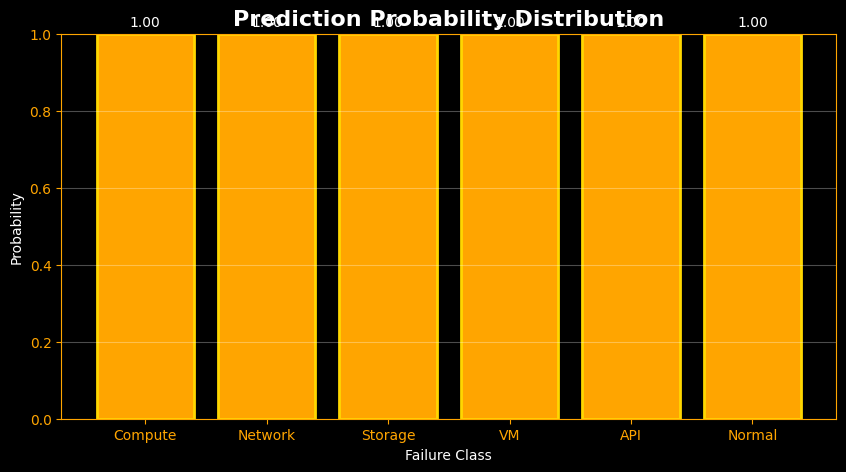

In [ ]:
classes = [
    "Compute",
    "Network",
    "Storage",
    "VM",
    "API",
    "Normal"
]

plt.figure(figsize=(10,5))

bars = plt.bar(
    classes,
    probabilities,
    color="orange",
    edgecolor="gold",
    linewidth=2
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Failure Class")

plt.ylabel("Probability")

plt.ylim(0,1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.02,
        f"{height:.2f}",
        ha="center",
        color="white",
        fontsize=10
    )

plt.grid(axis="y",alpha=.3)

plt.show()

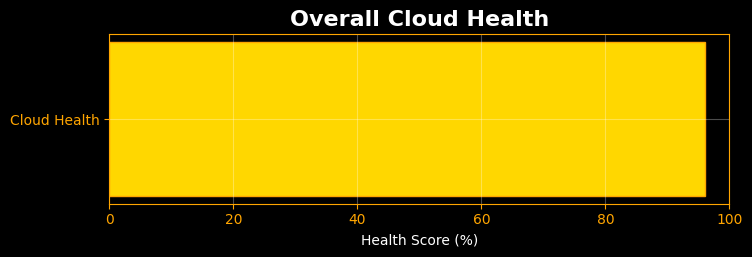

In [ ]:
plt.figure(figsize=(8,2.2))

plt.barh(
    ["Cloud Health"],
    [health],
    color="gold",
    edgecolor="orange",
    height=0.5
)

plt.xlim(0,100)

plt.xlabel("Health Score (%)")

plt.title("Overall Cloud Health")

plt.grid(alpha=.3)

plt.show()

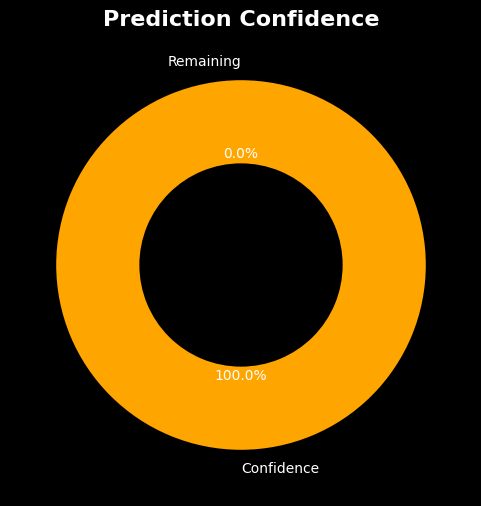

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    [confidence,100-confidence],
    labels=["Confidence","Remaining"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45),
    colors=["orange","gray"]
)

plt.title("Prediction Confidence")

plt.show()

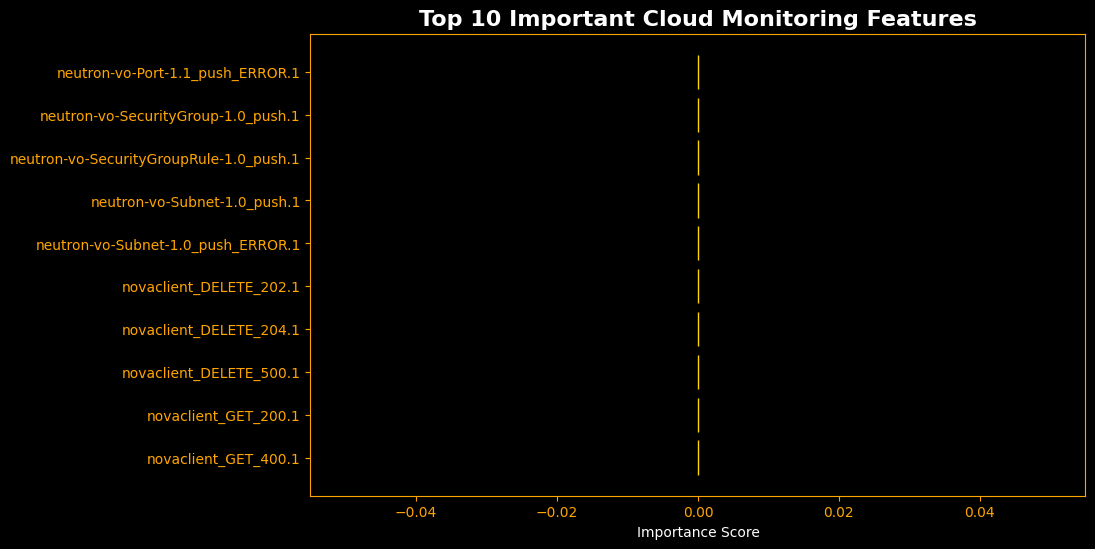

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": selected_columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color="orange",
    edgecolor="gold"
)

plt.title("Top 10 Important Cloud Monitoring Features")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

# Phase 9 :  Intelligent Prediction Summary

CloudSentinel successfully analysed the selected cloud infrastructure instance using a trained Random Forest classifier and generated an intelligent prediction report. The system identified the predicted failure category, estimated the prediction confidence, evaluated the overall cloud health, and determined the operational risk level.

Based on the prediction results, CloudSentinel generated a concise infrastructure assessment along with recommended corrective actions to assist cloud administrators in proactive monitoring and maintenance. This demonstrates how machine learning can be integrated into cloud operations to support intelligent decision-making and early failure prediction in real-world environments.

In [ ]:
print("="*70)
print("           CloudSentinel - Final Prediction Summary")
print("="*70)

print(f"\nPredicted Event      : {predicted_failure}")
print(f"Prediction Confidence: {confidence:.2f}%")
print(f"Cloud Health Score   : {health}%")
print(f"Risk Level           : {risk}")

print("\nInfrastructure Assessment")

if risk == "LOW":
    print("✓ Infrastructure is operating normally.")
    print("✓ Continue routine monitoring.")

elif risk == "MEDIUM":
    print("✓ Minor abnormalities detected.")
    print("✓ Monitor system performance and API services.")

elif risk == "HIGH":
    print("✓ Infrastructure stability is degrading.")
    print("✓ Administrator intervention is recommended.")

elif risk == "VERY HIGH":
    print("✓ High probability of service degradation.")
    print("✓ Immediate inspection of cloud resources is advised.")

else:
    print("✓ Critical infrastructure condition detected.")
    print("✓ Immediate corrective action is required.")

print("\nRecommended Actions")

for action in recommendations[prediction]:
    print("•", action)

print("\nCloudSentinel execution completed successfully.")

           CloudSentinel - Final Prediction Summary

Predicted Event      : Normal Cloud Operation
Prediction Confidence: 100.00%
Cloud Health Score   : 96%
Risk Level           : LOW

Infrastructure Assessment
✓ Infrastructure is operating normally.
✓ Continue routine monitoring.

Recommended Actions
• Cloud infrastructure is healthy
• Continue routine monitoring
• No immediate action required

CloudSentinel execution completed successfully.


# Conclusion

CloudSentinel successfully demonstrates a complete end-to-end machine learning solution for cloud infrastructure failure prediction using real-world cloud monitoring datasets. The project integrates data preprocessing, exploratory data analysis, feature engineering, feature selection, predictive modelling, visualization, and intelligent reporting within a unified workflow.

Two complementary datasets were utilized throughout the project. The Cloud Monitoring Dataset supported exploratory analysis and temporal visualization, while the OpenStack Failure Dataset enabled multi-class cloud failure prediction using a Random Forest classifier. The developed system provides an interactive cloud monitoring dashboard capable of predicting failure events, estimating cloud health, assessing operational risk, and generating meaningful recommendations for administrators.

The project illustrates how machine learning techniques can be applied to real-world cloud infrastructure monitoring to enable proactive maintenance, improve operational reliability, and support intelligent decision-making. Overall, CloudSentinel serves as a practical prototype of an AI-powered cloud operations platform capable of assisting administrators in monitoring and predicting infrastructure failures.